# Snapshot comparison

Compares a **candidate** BCSD run against a **snapshot** baseline, leaf by leaf, for exact
equality. Candidate and snapshot are separate stores read on their own icechunk branches
(`candidate_branch`, `snapshot_branch`), which need not match.

| mode | candidate | snapshot | trim |
|---|---|---|---|
| `southafrica` | regional | regional, same extent | `roi_bounds` |
| `global` | global | global | none |

The regional candidate is produced over a ~3 degree halo because BCSD's regrid and spatial
disaggregation have edge effects at the domain boundary. `roi_bounds` trims both runs back
to the region of interest so only cells with full neighborhoods are compared.

Five passes:

| pass | cell | what it answers |
|---|---|---|
| open and align | *Open the two runs* | do both stores read, and does the snapshot land on the candidate's grid |
| inventory | *Leaf inventory* | did the candidate write every configured leaf, and do the trees hold the same leaves |
| diff | *Compare* | does any leaf differ from the snapshot, and does `tasmax >= tasmin` hold |
| determinism | *Run-to-run determinism* | optional: are two independent runs of the same configs bit-identical |
| NaN audit | *Candidate NaN audit* | does the candidate hold a NaN inside the region of interest |
| plots | heatmap, maps, distributions | where and how the moving leaves move |

Parameterized with [papermill](https://papermill.readthedocs.io/): the first code cell is
tagged `parameters`, so `candidate_uri`, `candidate_branch`, `replicate_branch`, `mode`,
`roi_bounds`, `config_path`, `scenarios`, `variables`, and `time_index` can be overridden
at execution time. `snapshot_uri` and `snapshot_branch` are derived from `mode` in the next
cell and are **not** overridable. See `docs/explanation/snapshot-testing.md` for why this
check exists and how the merge decision is made.

## What this run is expected to show

The candidate is `v0.12.0.post18`, the `v0.12.0` tag plus the commits on branch
`g6-end-lineage-bridge`, and the baseline is `v0.12.0` from `srm.snapshot.baselines`. The
two runs share a tag, so everything already merged drops out and a leaf that moves here
moves because of this branch.

Unlike previous runs the two stores do **not** hold the same leaf set, because this branch
adds coverage rather than only changing numbers:

| | leaves | reading |
|---|---|---|
| shared | 50 | compared for exact equality |
| candidate only | 36 | new coverage, listed below |
| baseline only | 0 | nothing the baseline held went missing |

The 36 candidate-only leaves are `g6_1p5k_end` (14 including `debiased_coarse`),
`g6_1p5k/002` (14), and `historical/r2i1p1f1` (8). The termination scenario is new, member
`002` is newly published as its continued-SAI counterpart, and `r2i1p1f1` is the historical
parent the standard variables of member `002` resolve to, which member `003` never needed.
They have no baseline counterpart, so the comparison reports them one-sided; that is the
expected reading here, not a failure.

### The 50 shared leaves should not move

The bridge change only fires where `sai_parent` is set, which is `G6-1.5K-END` alone, so it
cannot touch `g6_1p5k/003` or `ssp245`. Nothing else on the branch changes a number: the
lineage tuple widened, the `predict_period_start` guard rejects configs rather than
altering them, and the reconciliation tooling only reads. So every one of the 50 shared
leaves should exactly match the snapshot, and one that does not is a real finding.

Baseline-only leaves are the signal that matters most here. Zero of them means no task
aborted and no previously covered leaf vanished while the leaf set was growing.


In [1]:
# The candidate is a separate store on its own branch; it need not match the snapshot.
# Set candidate_branch to whatever branch your SA run wrote to (the installed package
# version by default, unless you set BCSD_BRANCH when producing it).
#
# Snapshot runs write to the carbonplan-srm bucket. They were moved off
# carbonplan-scratch, whose bucket-wide lifecycle rule expires every object after 21
# days, which silently deleted store root anchors and left older branches unopenable.
# carbonplan-srm has no lifecycle configuration.
candidate_uri = (
    "s3://carbonplan-srm/snapshot/output/qa/CESM2-WACCM-ERA5-lat-38.0to-19.0_lon13.0to36.0.icechunk"
)
candidate_branch = "v0.13.0"
# "southafrica" = cheap check (subset the global snapshot to the candidate's extent);
# "global" = full change-detected path (candidate already global, no subset).
mode = "southafrica"
# Optional second candidate run: same configs, same commit, different branch. Set it to
# check that the pipeline is still deterministic before reading an exact-equality FAIL
# as a code change. None skips that pass.
replicate_branch = None

# The SA candidate is produced over a ~3 deg halo. roi_bounds trims both runs back to
# the region of interest before comparing, excluding BCSD edge effects at the halo
# boundary. [lat_min, lat_max, lon_min, lon_max]; set to None to compare the full extent.
roi_bounds = [-35, -22, 16, 33]
# Configs the candidate was produced from, relative to the repository root. The inventory
# cell loads them through the same loader `bcsd run` uses, so it can tell a leaf that was
# never configured from one that was configured and never written (a task aborted by an
# assert_no_nans gate, for instance).
config_path = "configs/snapshot/cesm2-waccm"
scenarios = None  # None = all groups; or e.g. ["g6_1p5k"]
variables = None  # None = all; or e.g. ["tas", "pr"]
time_index = 0

In [2]:
# Read from baselines.py rather than hardcoded here, so "which run is the baseline" stays
# a single version-controlled value. It resolves to v0.12.0, the published production run;
# the candidate is that same tag plus this branch's commits, which is what makes the diff
# attributable.

from srm.snapshot.baselines import CESM2_WACCM_GLOBAL, CESM2_WACCM_SOUTH_AFRICA

if mode == "southafrica":
    snapshot_uri = CESM2_WACCM_SOUTH_AFRICA.uri
    snapshot_branch = CESM2_WACCM_SOUTH_AFRICA.branch
elif mode == "global":
    snapshot_uri = CESM2_WACCM_GLOBAL.uri
    snapshot_branch = CESM2_WACCM_GLOBAL.branch

## Open the two runs

Opening the stores and aligning them onto a common grid is kept separate from diffing
them, so the inventory pass below can see both leaf sets exactly as they were read, before
any subsetting drops an unmatched node. Nothing here reads array data, so this cell is
fast even against the global store; the reductions all happen further down.

In [3]:
import xarray as xr

from srm.snapshot.compare import _iter_leaf_datasets
from srm.validation import _open_output_datatree


def crop_to_roi(ds, bounds):
    """Select the cells of ``ds`` inside [lat_min, lat_max, lon_min, lon_max]."""
    lat_min, lat_max, lon_min, lon_max = bounds
    idx = {}
    if "lat" in ds.coords:
        idx["lat"] = ds.lat[(ds.lat >= lat_min) & (ds.lat <= lat_max)]
    if "lon" in ds.coords:
        idx["lon"] = ds.lon[(ds.lon >= lon_min) & (ds.lon <= lon_max)]
    return ds.sel(idx) if idx else ds


candidate_tree = _open_output_datatree(candidate_uri, branch=candidate_branch)
snapshot_tree = _open_output_datatree(snapshot_uri, branch=snapshot_branch)

# Leaf paths as read, captured before the subsetting below drops anything. The inventory
# cell diffs these, so a leaf present on only one side is reported rather than lost.
candidate_paths = {path for path, _ in _iter_leaf_datasets(candidate_tree)}
snapshot_paths = {path for path, _ in _iter_leaf_datasets(snapshot_tree)}

if mode == "southafrica":
    # Trim the candidate to the region of interest (drop the halo), then subset the
    # global snapshot to those exact cells. Plain .sel: raises if a coordinate is
    # missing, so grid drift fails loudly (no coordinate resetting).
    cand_leaves = {
        path: (crop_to_roi(ds, roi_bounds) if roi_bounds else ds)
        for path, ds in _iter_leaf_datasets(candidate_tree)
    }
    snap_subset = {}
    for path, snap_ds in _iter_leaf_datasets(snapshot_tree):
        c = cand_leaves.get(path)
        if c is None:
            # Snapshot-only leaf: the global baseline can carry ensemble members the
            # regional candidate never ran (e.g. historical/tas/r1i1p1f1). Dropping it
            # keeps the subset tree on the candidate's extent, since an unmatched leaf
            # would otherwise be copied through at the full global 721x1440. It is
            # *reported* by the inventory cell rather than silently skipped, because a
            # task aborted by an assert_no_nans gate would present the same way.
            continue
        idx = {d: c[d] for d in ("lat", "lon") if d in c.coords and d in snap_ds.coords}
        if idx:
            snap_ds = snap_ds.sel(idx)
        snap_subset["/" + path if path else "/"] = snap_ds
    candidate_tree = xr.DataTree.from_dict(
        {"/" + p if p else "/": ds for p, ds in cand_leaves.items()}
    )
    snapshot_tree = xr.DataTree.from_dict(snap_subset)

print(f"candidate {candidate_branch}: {len(candidate_paths)} leaves at {candidate_uri}")
print(f"snapshot  {snapshot_branch}: {len(snapshot_paths)} leaves at {snapshot_uri}")

candidate v0.12.0.post18: 86 leaves at s3://carbonplan-scratch/srm/output/qa/CESM2-WACCM-ERA5-lat-38.0to-19.0_lon13.0to36.0.icechunk
snapshot  regional-rerun-v0.12.0: 50 leaves at s3://carbonplan-scratch/srm/output/qa/CESM2-WACCM-ERA5-lat-38.0to-19.0_lon13.0to36.0.icechunk


## Leaf inventory

A leaf the candidate never wrote is not the same thing as a leaf that drifted, and the
diff report cannot tell them apart on its own: the subsetting above drops any leaf
missing from the candidate, so an aborted task would leave no trace in the diff. With the
`assert_no_nans` gates in place a task can now abort mid-run, which makes this the check
that turns that into a visible failure.

The expected leaf set comes from the snapshot configs themselves, loaded through
`srm.cli.load_configs`, the same loader `bcsd run` used to submit them. Only scenario
groups are reconstructed. `historical` leaves are keyed by *lineage* member rather than
the configured one (`tas` takes `r3i1p1f1` while `tasmax` takes `001`), so rebuilding them
here would duplicate `srm.lineage`; the candidate-versus-snapshot leaf diff covers them
instead.

In [4]:
import pathlib

from srm.cli import load_configs
from srm.config import SCENARIO_TO_GROUP


def repo_root() -> pathlib.Path:
    """Nearest ancestor of the working directory that holds pyproject.toml."""
    here = pathlib.Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError(f"could not locate the repository root from {here}")


configs, config_options = load_configs(str(repo_root() / config_path))
configured = {f"{SCENARIO_TO_GROUP[c.scenario]}/{c.variable}/{c.ensemble_member}" for c in configs}
# debiased_coarse mirrors the scenario groups one level down and is compared, but it is
# not what the configs enumerate, so it is excluded from the expected-set diff.
written = {path for path in candidate_paths if not path.startswith("debiased_coarse")}

never_written = sorted(configured - written)
snapshot_only = sorted(snapshot_paths - candidate_paths)
candidate_only = sorted(candidate_paths - snapshot_paths)
inventory_ok = not (never_written or snapshot_only or candidate_only)

print("INVENTORY:", "PASS" if inventory_ok else "FAIL")
print(f"  {len(configs)} configs -> {len(configured)} configured scenario-group leaves")
print(f"  candidate holds {len(candidate_paths)} leaves, snapshot holds {len(snapshot_paths)}")
if config_options.branch != candidate_branch:
    # Not a failure: the configs' default branch tracks the *installed* package version,
    # which moves when you reinstall. Worth seeing, because reading the wrong branch is
    # the easiest way to compare against a run you did not just produce.
    print(
        f"  note: configs default to branch {config_options.branch!r}, reading {candidate_branch!r}"
    )
for label, paths in (
    ("configured but never written by the candidate", never_written),
    ("in the snapshot only, dropped from the diff", snapshot_only),
    ("in the candidate only, reported as a mismatch", candidate_only),
):
    for path in paths:
        print(f"  {label}: {path}")

INVENTORY: FAIL
  32 configs -> 32 configured scenario-group leaves
  candidate holds 86 leaves, snapshot holds 50
  note: configs default to branch 'v0.12.0.post29', reading 'v0.12.0.post18'
  in the candidate only, reported as a mismatch: debiased_coarse/g6_1p5k/dtr/002
  in the candidate only, reported as a mismatch: debiased_coarse/g6_1p5k/hurs/002
  in the candidate only, reported as a mismatch: debiased_coarse/g6_1p5k/pr/002
  in the candidate only, reported as a mismatch: debiased_coarse/g6_1p5k/rsds/002
  in the candidate only, reported as a mismatch: debiased_coarse/g6_1p5k/tas/002
  in the candidate only, reported as a mismatch: debiased_coarse/g6_1p5k/tasmax/002
  in the candidate only, reported as a mismatch: debiased_coarse/g6_1p5k/tasmin/002
  in the candidate only, reported as a mismatch: debiased_coarse/g6_1p5k_end/dtr/002
  in the candidate only, reported as a mismatch: debiased_coarse/g6_1p5k_end/hurs/002
  in the candidate only, reported as a mismatch: debiased_coars

## Compare

`_compare_datatrees` reduces every leaf to `max_abs_diff`, `rmse`, `frac_over_tol`, and
`nan_mismatch_count`, then runs the `tasmax >= tasmin` invariant on the candidate alone.

**`within_tol` is the verdict; `frac_over_tol` is not.** The verdict comes from
`xr.testing.assert_equal` (or `assert_allclose` when a tolerance band is passed), which
also checks dimension names and index identity. `frac_over_tol` is a cell count for
ranking and plotting, and the two can disagree: a snapshot cell holding `inf` has no
finite difference to exceed a tolerance, so `frac_over_tol` reads 0.0 on a leaf the
assertion rejects. Rank on it, never gate on it.

Three ways a leaf fails:

| failure | signature |
|---|---|
| a value moved | `frac_over_tol > 0` |
| NaN on one side only | `nan_mismatch_count > 0` |
| structural | `frac_over_tol = 1.0`, `nan_mismatch_count = -1`, `shape_mismatch = True` |

The structural sentinel covers three distinct causes and does not distinguish them: a
candidate leaf with no snapshot counterpart, two leaves whose coordinates do not align,
and two leaves whose dimension names differ. Only the first is expected. Cross-check
against *Leaf inventory*: a sentinel on a leaf that inventory reports as shared is a grid
regression, not new coverage.

In [5]:
from srm.snapshot.runs import _compare_datatrees

report = _compare_datatrees(candidate_tree, snapshot_tree, scenarios=scenarios, variables=variables)

# OVERALL folds two verdicts: no leaf differs from the snapshot, and the
# candidate's tasmax >= tasmin invariant holds (a broken reconcile can pass every leaf
# individually yet invert the pair; see report.invariant_checks below).
print("OVERALL:", "PASS" if report.passed else "FAIL")
print(f"      {'leaf':44s} {'max_abs':>11s} {'rmse':>11s} {'frac>tol':>10s} {'nan_mism':>9s}")
for leaf in sorted(report.leaves, key=lambda lf: lf.path):
    flag = "ok " if leaf.within_tol else "OUT"
    print(
        f"[{flag}] {leaf.path:44s} {leaf.max_abs_diff:11.3e} {leaf.rmse:11.3e} "
        f"{leaf.frac_over_tol:10.3e} {leaf.nan_mismatch_count:9d}"
    )
for check in sorted(report.invariant_checks, key=lambda c: c.path):
    flag = "ok " if check.holds else "OUT"
    print(f"[{flag}] {check.path:44s} {check.detail}")

# Roll-up by group. The model_hist fix (issue #518) is expected to move g6_1p5k and leave
# ssp245 and historical alone, so the verdict is most legible split this way.
tallies: dict[str, list[int]] = {}
for leaf in report.leaves:
    parts = leaf.path.split("/")
    key = "debiased_coarse/" + parts[1] if parts[0] == "debiased_coarse" else parts[0]
    tally = tallies.setdefault(key, [0, 0])
    tally[0] += 1
    tally[1] += 0 if leaf.within_tol else 1
print()
for key in sorted(tallies):
    total, out = tallies[key]
    print(f"  {key:28s} {total - out:2d}/{total:2d} leaves match exactly")

OVERALL: FAIL
      leaf                                             max_abs        rmse   frac>tol  nan_mism
[OUT] debiased_coarse/g6_1p5k/dtr/002/dtr                  nan         nan  1.000e+00        -1
[ok ] debiased_coarse/g6_1p5k/dtr/003/dtr            0.000e+00   0.000e+00  0.000e+00         0
[OUT] debiased_coarse/g6_1p5k/hurs/002/hurs                nan         nan  1.000e+00        -1
[ok ] debiased_coarse/g6_1p5k/hurs/003/hurs          0.000e+00   0.000e+00  0.000e+00         0
[OUT] debiased_coarse/g6_1p5k/pr/002/pr                    nan         nan  1.000e+00        -1
[ok ] debiased_coarse/g6_1p5k/pr/003/pr              0.000e+00   0.000e+00  0.000e+00         0
[OUT] debiased_coarse/g6_1p5k/rsds/002/rsds                nan         nan  1.000e+00        -1
[ok ] debiased_coarse/g6_1p5k/rsds/003/rsds          0.000e+00   0.000e+00  0.000e+00         0
[OUT] debiased_coarse/g6_1p5k/tas/002/tas                  nan         nan  1.000e+00        -1
[ok ] debiased_coarse/g6_1

## Run-to-run determinism

Exact equality against a baseline only means something if the pipeline is reproducible.
Two independent runs of the same configs at the same commit must be bit-identical; if they
are not, a FAIL above says nothing about the code under review.

Produce a second run and set `replicate_branch`:

```
uv run bcsd run --config-path configs/snapshot/cesm2-waccm/ --branch <name>
uv run bcsd run --config-path configs/snapshot/cesm2-waccm/ --branch <name>-take2
```

This pass probes the `debiased_coarse` leaves only. They are ~20x smaller than the final
products and sit upstream of spatial disaggregation, so nondeterminism reaches them first.
Both runs share a grid, so nothing is trimmed and the halo is compared too.

To check every leaf instead, run `compare_runs(candidate_uri, candidate_uri,
candidate_branch=..., snapshot_branch=replicate_branch)`. Do that where the data is: it
reads both runs in full (~77 GB for the SA tree) and takes over ten minutes from a laptop.
Note `scenarios` and `variables` filter the *report*, not the work, so they do not make it
cheaper.

In [6]:
from srm.snapshot.compare import _compare_dataarray
from srm.validation import _open_output_datatree


def leaf_paths(tree, prefix="debiased_coarse/"):
    """(path, variable) for every leaf under ``prefix``.

    Built from subtree_with_keys, not `path in tree`: DataTree membership tests direct
    child names, so a full path always reports missing and every leaf silently skips.
    """
    return {
        (path, str(variable))
        for path, node in tree.subtree_with_keys
        if path.startswith(prefix)
        for variable in node.to_dataset(inherit=False).data_vars
    }


if replicate_branch is None:
    print("replicate_branch is None; skipping. Set it to a second run of the same configs.")
else:
    replicate_tree = _open_output_datatree(candidate_uri, branch=replicate_branch)
    wanted = {
        (path, variable)
        for path, variable in leaf_paths(candidate_tree)
        if (scenarios is None or path.split("/")[1] in scenarios)
        and (variables is None or variable in variables)
    }
    available = leaf_paths(replicate_tree)
    # A leaf the replicate run never wrote cannot be checked. Count it as a failure:
    # a determinism pass that skips everything must not report PASS.
    missing = sorted(wanted - available)
    moved = []
    print(f"{candidate_branch} vs {replicate_branch}: probing {len(wanted)} coarse leaves")
    for path, variable in sorted(wanted & available):
        diff = _compare_dataarray(
            candidate_tree[path].to_dataset(inherit=False)[variable],
            replicate_tree[path].to_dataset(inherit=False)[variable],
            path=path,
            variable=variable,
        )
        if not diff.within_tol:
            moved.append(diff)
            print(f"  [OUT ] {path:44s} max_abs={diff.max_abs_diff:.3e}")
    for path, variable in missing:
        print(f"  [MISS] {path:44s} not written by {replicate_branch}")
    determinism_ok = not moved and not missing and bool(wanted)
    print(
        "DETERMINISM:",
        "PASS"
        if determinism_ok
        else f"FAIL ({len(moved)} differing, {len(missing)} missing, {len(wanted)} probed)",
    )

replicate_branch is None; skipping. Set it to a second run of the same configs.


## Candidate NaN audit

Inside `roi_bounds` the candidate should hold no NaN at all. The fine cells that
interpolate to NaN by design sit in the halo, outside the region of interest (see
`srm.downscaling_utils.coarse_domain_mask`), and the `assert_no_nans` gates now abort a
task rather than write an interior NaN. So a nonzero candidate fraction here is a
regression, and it is the direct end-to-end check on issue #517.

Pairing that fraction with `nan_mismatch_count` from the report above tells you which side
holds the NaNs, without a second read of the global snapshot:

| candidate NaN frac | `nan_mismatch` | reading |
|---|---|---|
| 0 | 0 | both sides clean |
| 0 | > 0 | the **snapshot** holds the NaNs, so the fix landed |
| > 0 | > 0 | the **candidate** holds NaNs the baseline does not, so it is a regression |
| > 0 | 0 | both sides NaN at the same cells, so the bug predates the baseline |

This reduces over the full candidate extent, which is a few GB of regional reads in
`southafrica` mode and considerably more in `global` mode. It adds roughly one pass over
the candidate on top of what the compare cell already reads, and it touches only the
candidate, never the snapshot.

In [7]:
# nan_mismatch comes from the report above, so the global snapshot is not read again.
mismatch = {leaf.path: leaf.nan_mismatch_count for leaf in report.leaves}
nan_rows = []
for path, cand_ds in sorted(_iter_leaf_datasets(candidate_tree), key=lambda item: item[0]):
    for variable, cand_da in cand_ds.data_vars.items():
        leaf_path = f"{path}/{variable}"
        if leaf_path not in mismatch:
            continue  # filtered out by `scenarios` / `variables`
        nan_rows.append((leaf_path, float(cand_da.isnull().mean().compute()), mismatch[leaf_path]))

candidate_nan_leaves = [row for row in nan_rows if row[1] > 0]
print(
    "CANDIDATE NaN AUDIT:",
    "PASS (no NaN inside the region of interest)" if not candidate_nan_leaves else "FAIL",
)
print(f"      {'leaf':44s} {'cand nan frac':>14s} {'nan_mismatch':>13s}")
for leaf_path, frac, mism in nan_rows:
    flag = "ok " if frac == 0 else "NaN"
    print(f"[{flag}] {leaf_path:44s} {frac:14.6f} {mism:13d}")

CANDIDATE NaN AUDIT: PASS (no NaN inside the region of interest)
      leaf                                          cand nan frac  nan_mismatch
[ok ] debiased_coarse/g6_1p5k/dtr/002/dtr                0.000000            -1
[ok ] debiased_coarse/g6_1p5k/dtr/003/dtr                0.000000             0
[ok ] debiased_coarse/g6_1p5k/hurs/002/hurs              0.000000            -1
[ok ] debiased_coarse/g6_1p5k/hurs/003/hurs              0.000000             0
[ok ] debiased_coarse/g6_1p5k/pr/002/pr                  0.000000            -1
[ok ] debiased_coarse/g6_1p5k/pr/003/pr                  0.000000             0
[ok ] debiased_coarse/g6_1p5k/rsds/002/rsds              0.000000            -1
[ok ] debiased_coarse/g6_1p5k/rsds/003/rsds              0.000000             0
[ok ] debiased_coarse/g6_1p5k/tas/002/tas                0.000000            -1
[ok ] debiased_coarse/g6_1p5k/tas/003/tas                0.000000             0
[ok ] debiased_coarse/g6_1p5k/tasmax/002/tasmax        

## Where the leaves move

One cell per compared leaf, colored by the fraction of grid cells differing from the
snapshot. Rows are `variable/member`, columns are the scenario group.

- **Gray** — compared, `frac_over_tol = 0.0`: nothing moved.
- **Red** — compared, some fraction of cells differ; darker is more of the grid.
- **Hatched dark red** — `shape_mismatch`, so no cell-by-cell measurement was made. Either
  the leaf has no snapshot counterpart (expected here: every `.../002` and `.../r2i1p1f1`
  cell), or the two leaves sit on mismatched grids or carry different dimension names
  (a regression). *Leaf inventory* tells you which.
- **Blank** — no such `row x col` leaf exists (e.g. `g6_1p5k_end` has no member `003`).

The hatch is not a 100% mismatch. It marks a leaf the diff could not measure.

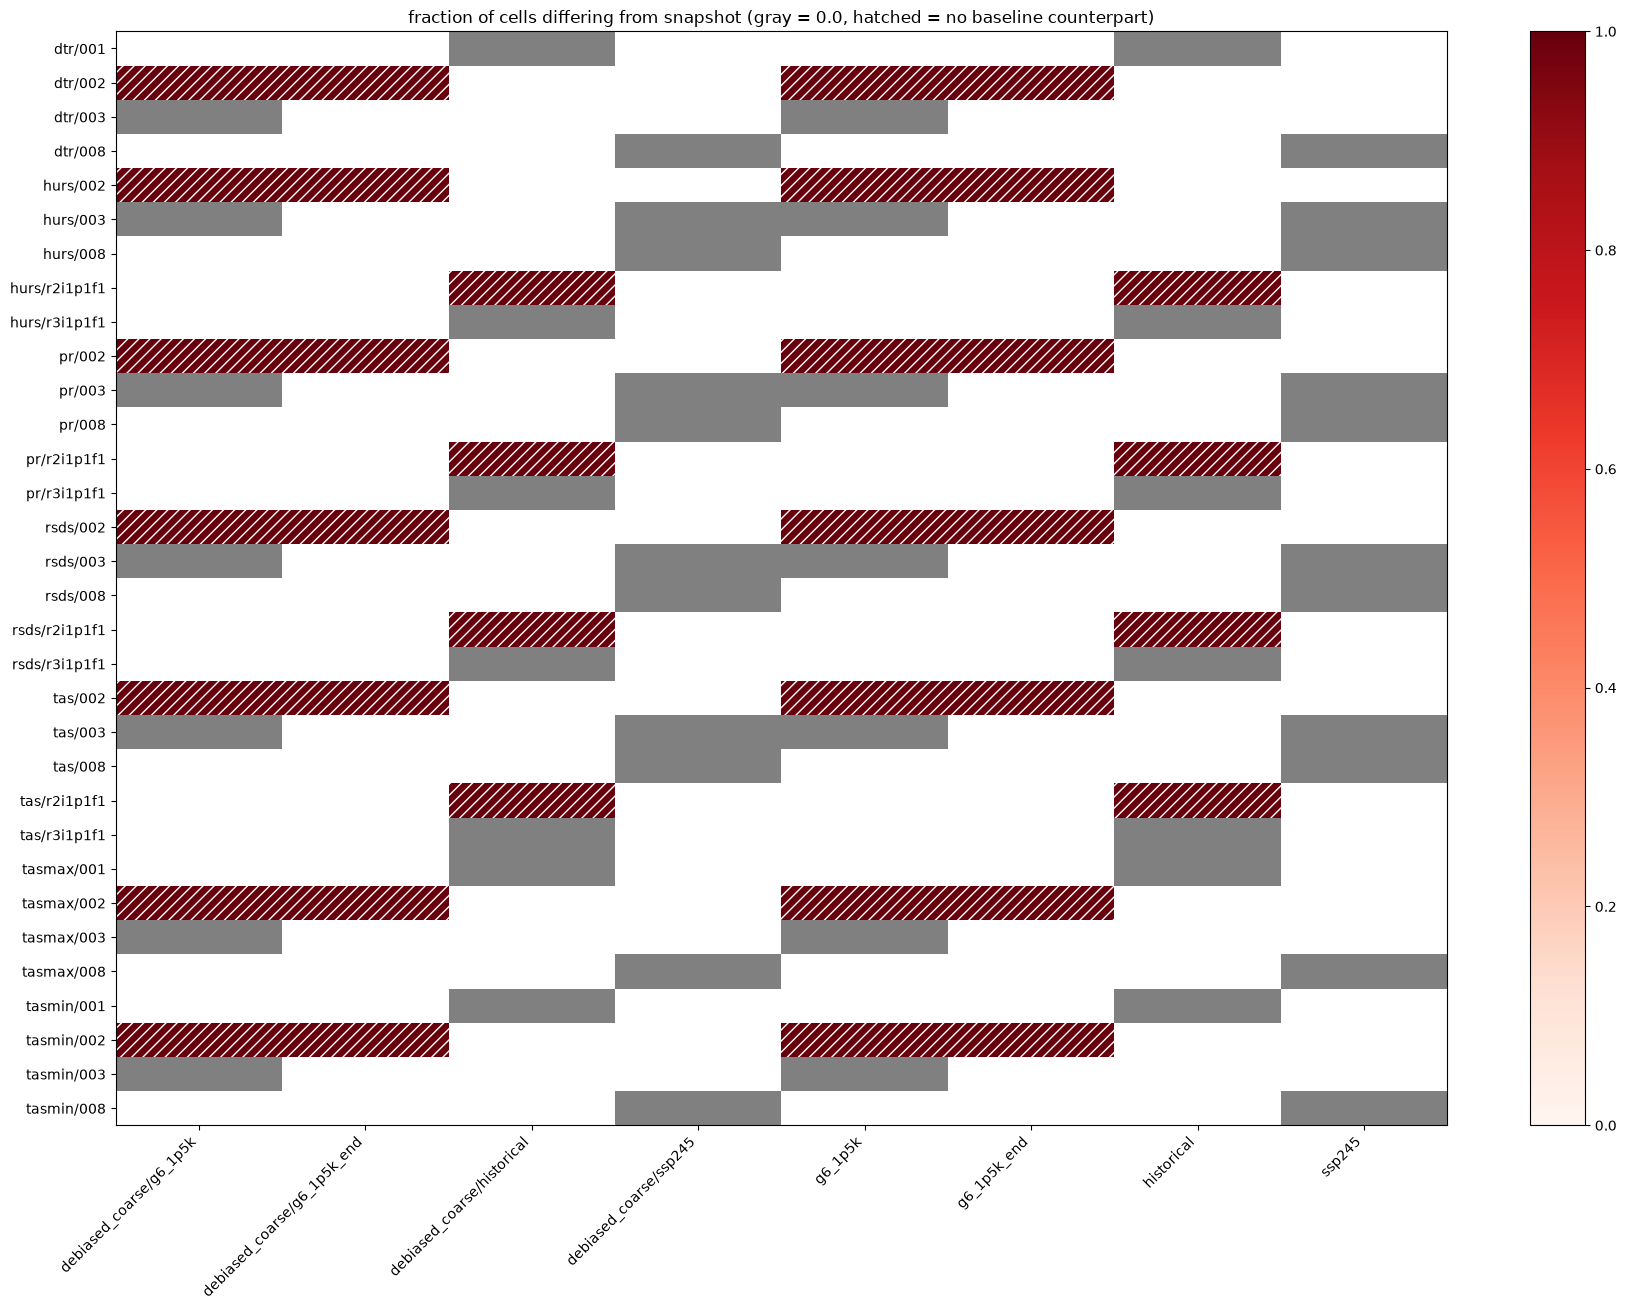

col,debiased_coarse/g6_1p5k,debiased_coarse/g6_1p5k_end,debiased_coarse/historical,debiased_coarse/ssp245,g6_1p5k,g6_1p5k_end,historical,ssp245
row,,,,,,,,
dtr/001,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN
dtr/002,1.0,1.0,NaN,NaN,1.0,1.0,NaN,NaN
dtr/003,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN
dtr/008,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0
hurs/002,1.0,1.0,NaN,NaN,1.0,1.0,NaN,NaN
hurs/003,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0
hurs/008,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0
hurs/r2i1p1f1,NaN,NaN,1.0,NaN,NaN,NaN,1.0,NaN
hurs/r3i1p1f1,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN


In [8]:
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Rows are keyed on variable *and* member. Keying on the variable alone collapsed sibling
# members onto one cell (ssp245/tas/003 and ssp245/tas/008 landed together and one
# silently overwrote the other). Leaf paths are group/variable/member/variable, with an
# extra debiased_coarse prefix on the coarse family, so counting from the right is stable.
records = []
for leaf in report.leaves:
    parts = leaf.path.split("/")
    if len(parts) < 4:
        continue
    family = "debiased_coarse/" if parts[0] == "debiased_coarse" else ""
    group, variable, member = parts[-4], parts[-3], parts[-2]
    records.append(
        {
            "row": f"{variable}/{member}",
            "col": f"{family}{group}",
            "frac_over_tol": leaf.frac_over_tol,
            "shape_mismatch": leaf.shape_mismatch,
        }
    )

if not records:
    raise ValueError("no leaves to plot; check the `scenarios` and `variables` filters")

leaf_df = pd.DataFrame(records)
grid = (
    leaf_df.pivot(index="row", columns="col", values="frac_over_tol")
    .sort_index()
    .sort_index(axis=1)
)
# shape_mismatch marks a candidate-only leaf (no baseline counterpart to diff against;
# see the Compare cell above), reindexed onto the same row/col order as `grid`.
mismatch_grid = (
    leaf_df.pivot(index="row", columns="col", values="shape_mismatch")
    .reindex(index=grid.index, columns=grid.columns)
    .fillna(False)
)

# Three leaf states get three treatments, since a single Reds imshow makes them
# indistinguishable: gray for a real zero (compared, nothing moved), the Reds/colorbar
# scale for real drift, and a white hatch over the darkest red for compare()'s sentinel
# (frac_over_tol=1.0 assigned when there is no baseline leaf to compare against at all --
# a structural mismatch, not a measured 100% mismatch). Cells with no entry in
# `grid` at all (e.g. g6_1p5k_end has no member 003) stay transparent background.
values = grid.to_numpy()
mismatch = mismatch_grid.to_numpy()
zero_mask = values == 0.0
nan_mask = np.isnan(values)

fig, ax = plt.subplots(figsize=(2.0 * len(grid.columns) + 2, 0.35 * len(grid.index) + 2))
gray_layer = np.where(zero_mask, 0.0, np.nan)
ax.imshow(gray_layer, aspect="auto", cmap=mcolors.ListedColormap(["gray"]))
colored_layer = np.where(zero_mask | nan_mask, np.nan, values)
im = ax.imshow(colored_layer, aspect="auto", cmap="Reds", vmin=0)
for (row_idx, col_idx), is_mismatch in np.ndenumerate(mismatch):
    if is_mismatch:
        ax.add_patch(
            mpatches.Rectangle(
                (col_idx - 0.5, row_idx - 0.5),
                1,
                1,
                fill=False,
                hatch="///",
                edgecolor="white",
                linewidth=0,
            )
        )
ax.set_xticks(range(len(grid.columns)), grid.columns, rotation=45, ha="right")
ax.set_yticks(range(len(grid.index)), grid.index)
ax.set_title(
    "fraction of cells differing from snapshot (gray = 0.0, hatched = no baseline counterpart)"
)
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()
grid

In [9]:
# The report above covers all leaves (including debiased_coarse); the plots below focus
# on the final products for readability. candidate_tree and snapshot_tree (already
# subset for the southafrica mode) come from the open-the-runs cell, and
# SCENARIO_TO_GROUP from the inventory cell.
KNOWN_GROUPS = set(SCENARIO_TO_GROUP.values())
scen_list = scenarios or sorted(
    KNOWN_GROUPS & set(snapshot_tree.children) & set(candidate_tree.children)
)


def leaf_da(tree, scenario, variable, member):
    """Return the DataArray for one (scenario, variable, member) leaf.

    The member is passed in explicitly rather than discovered, because a leaf can hold
    several ensemble members (e.g. historical/tas has r1i1p1f1, r2i1p1f1, r3i1p1f1). The
    caller pairs snapshot and candidate on the *same* member via :func:`shared_members`,
    so the difference is always like-for-like.
    """
    return tree[f"{scenario}/{variable}/{member}"].to_dataset(inherit=False)[variable]


def shared_members(scenario, variable):
    """Ensemble members present under this leaf in both the snapshot and candidate.

    Sorted for a stable plot order. The global snapshot may carry members the regional
    candidate never ran; those are excluded so only comparable pairs are plotted.
    """
    snap = set(snapshot_tree[f"{scenario}/{variable}"].children)
    cand = set(candidate_tree[f"{scenario}/{variable}"].children)
    return sorted(snap & cand)

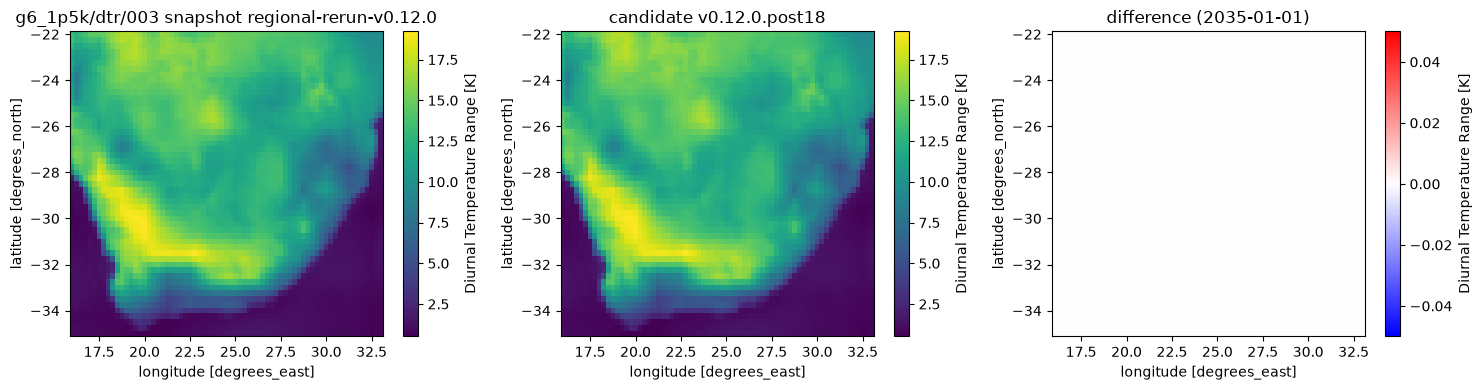

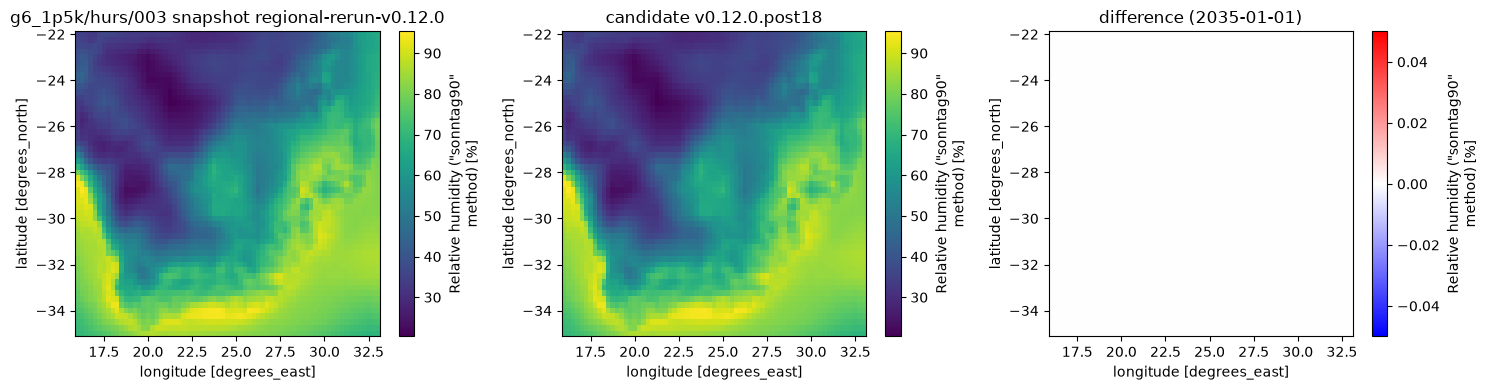

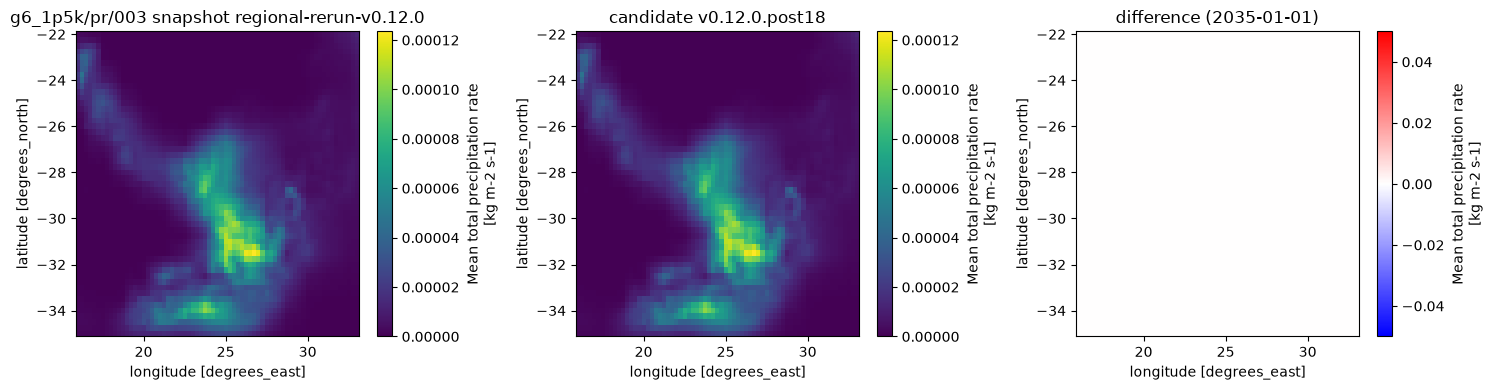

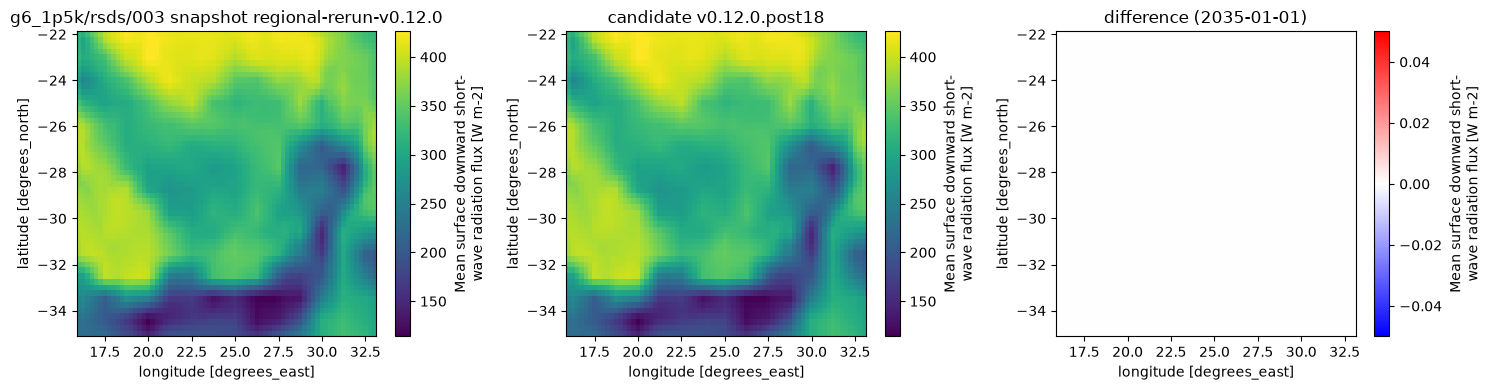

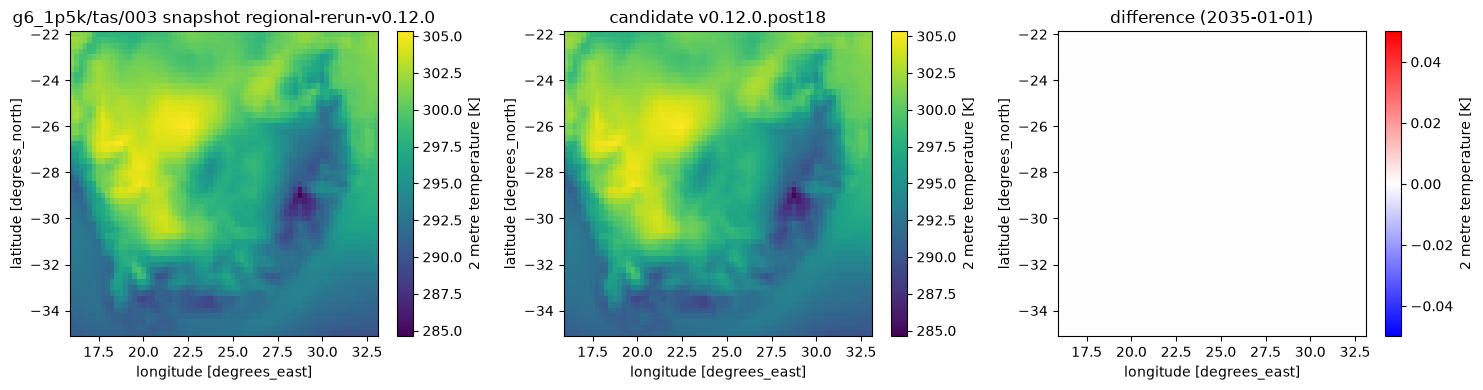

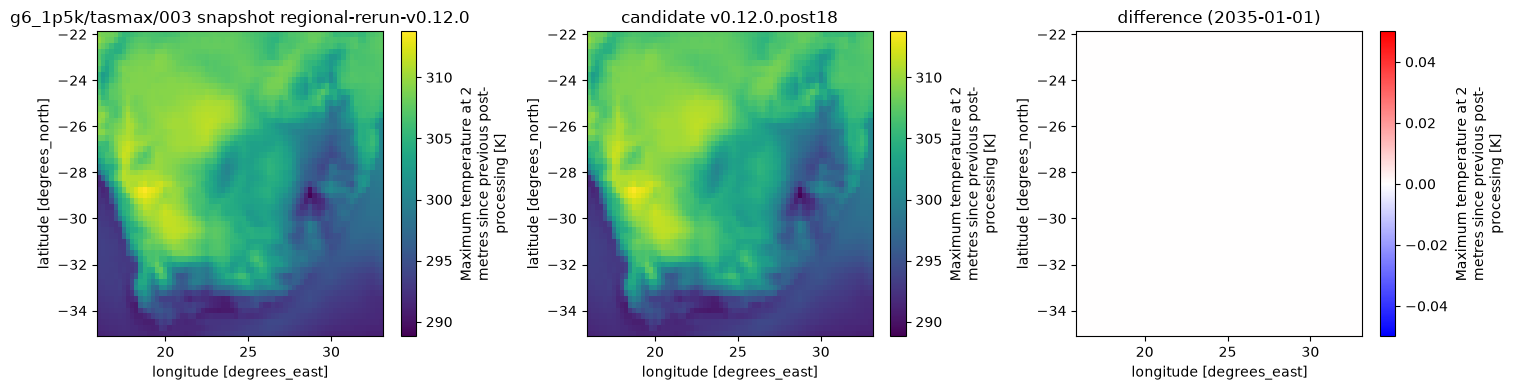

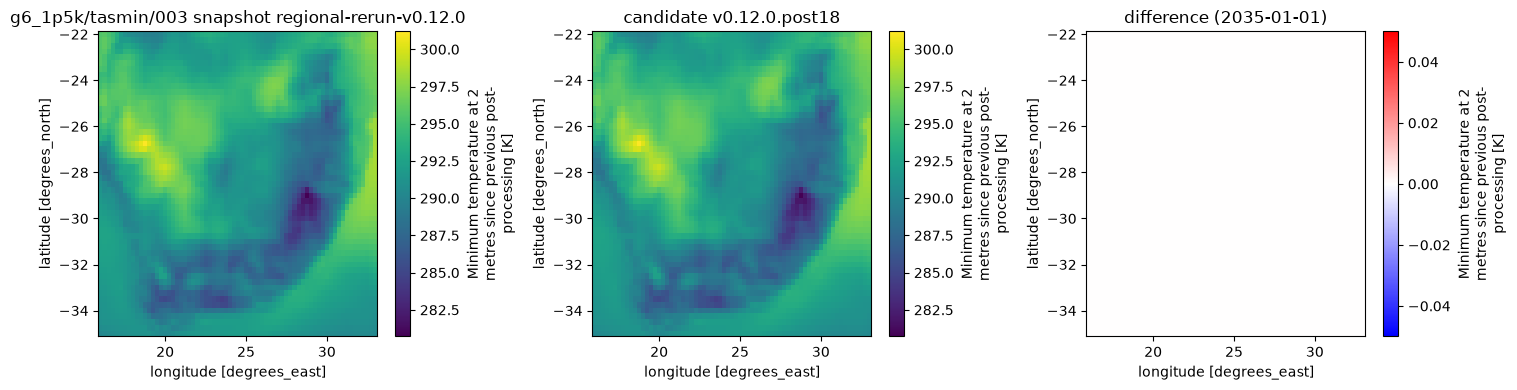

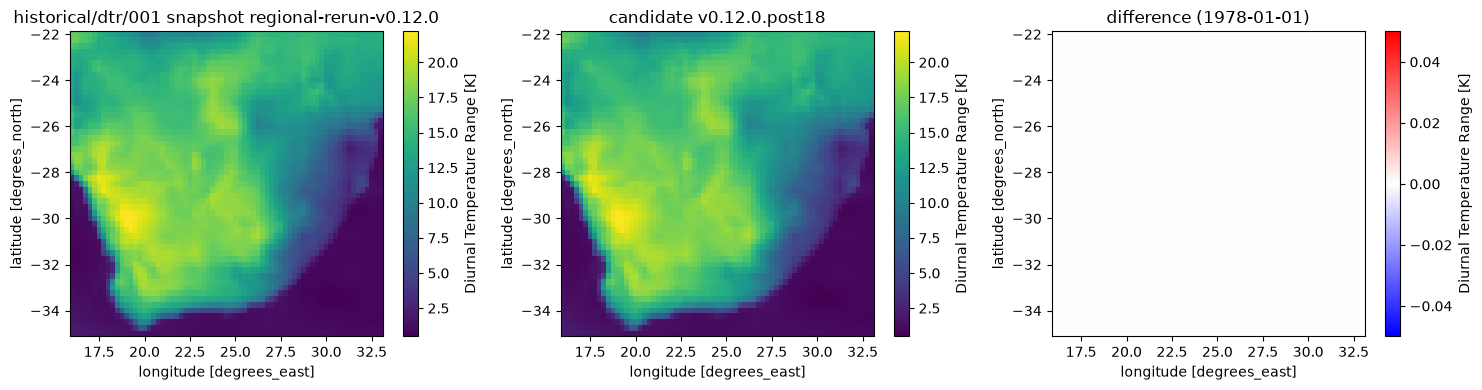

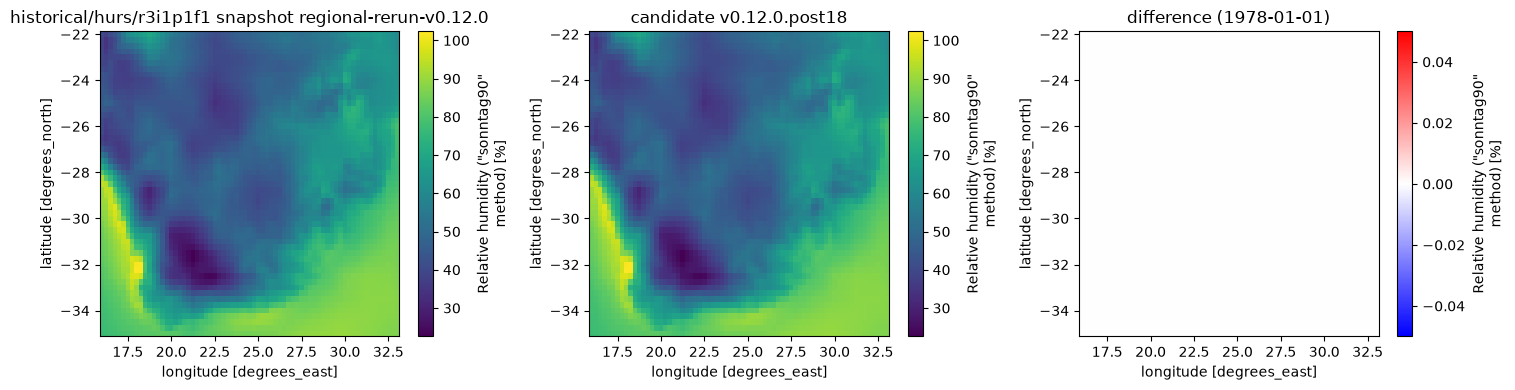

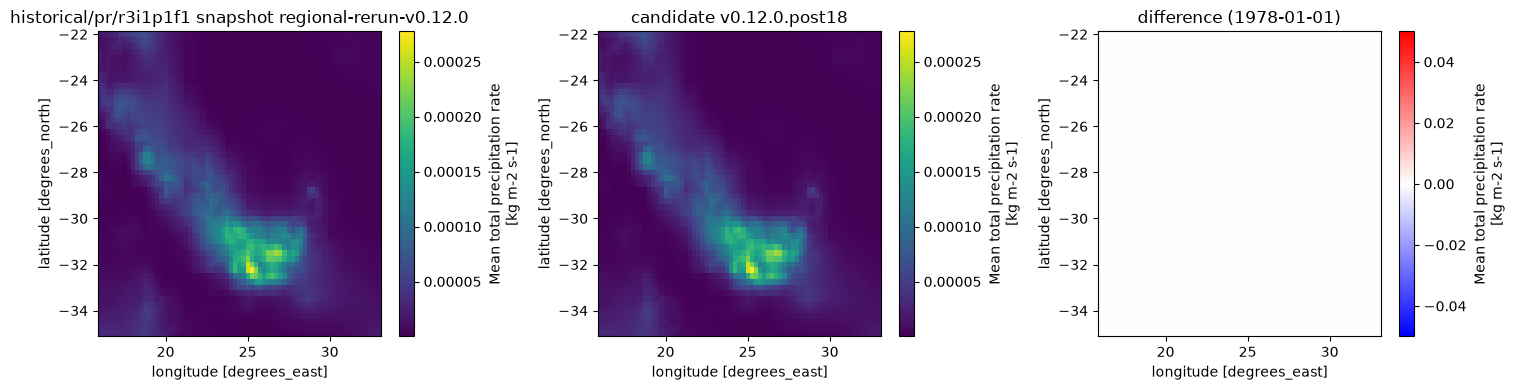

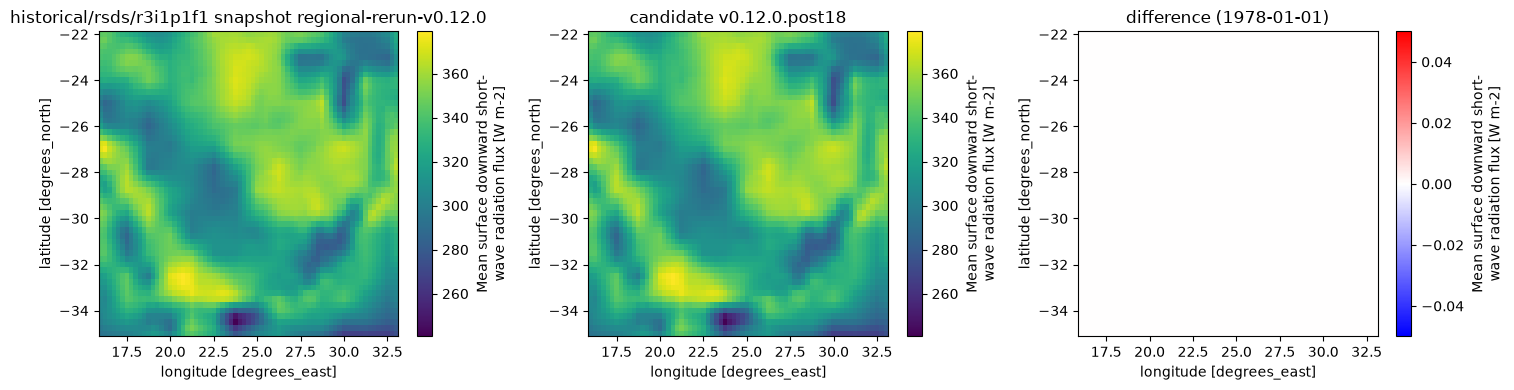

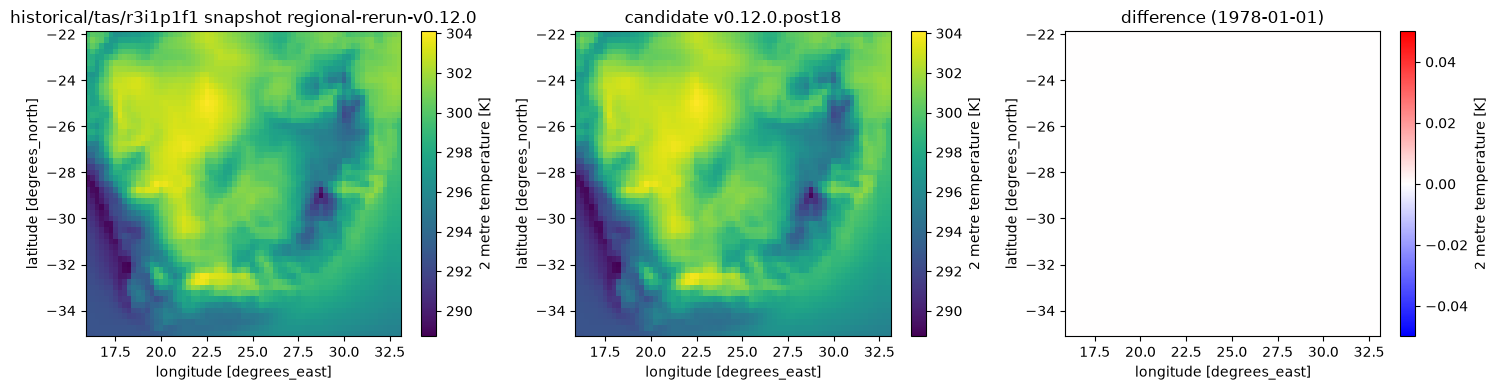

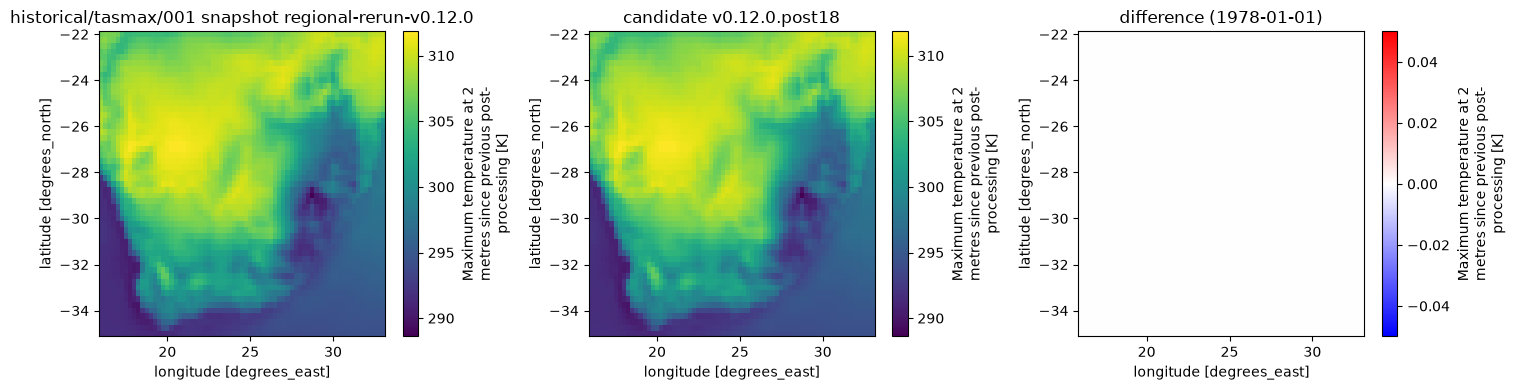

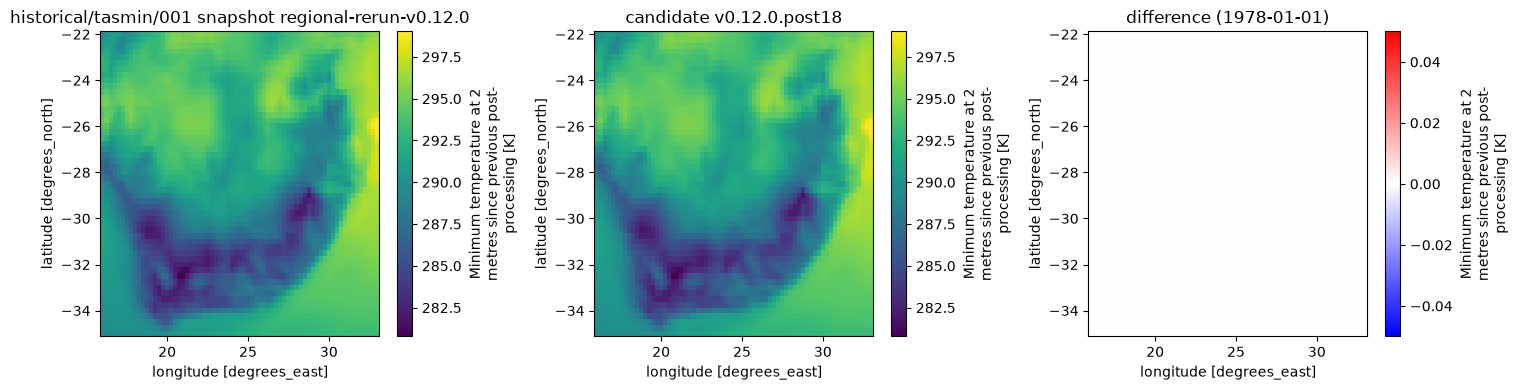

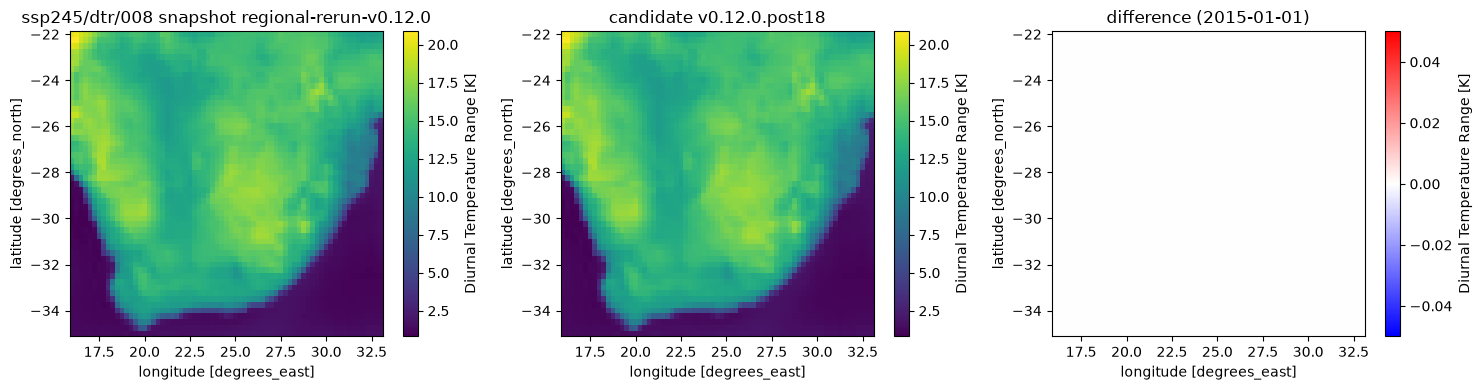

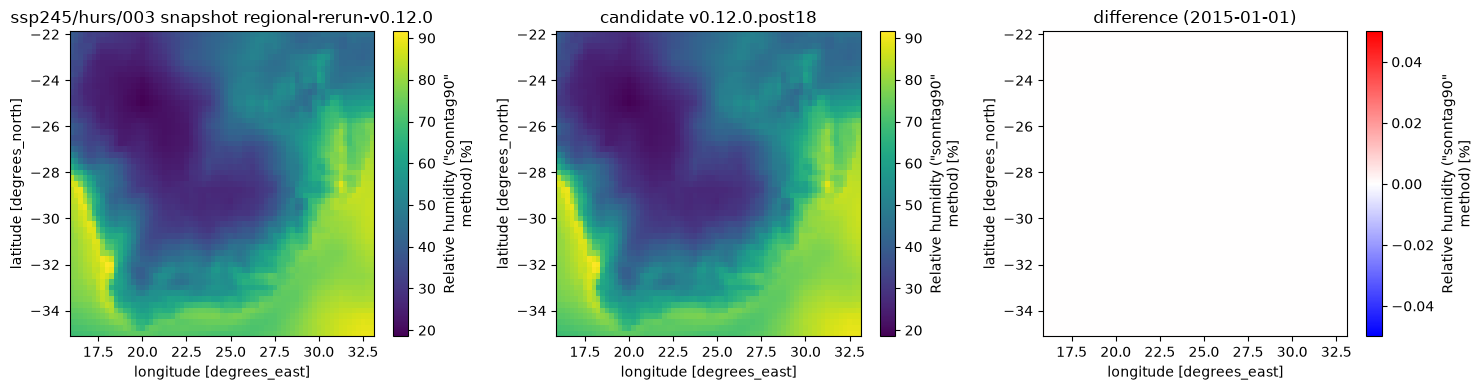

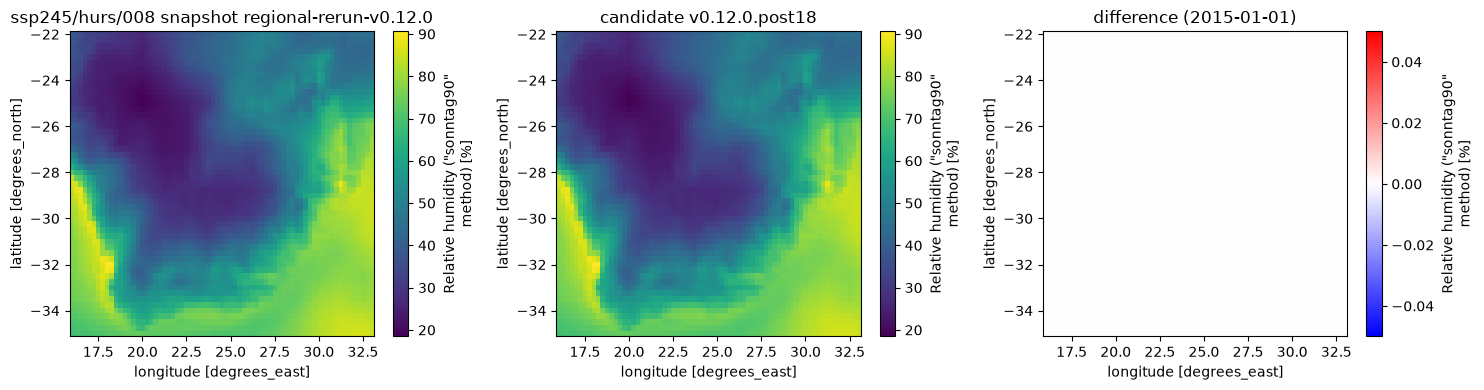

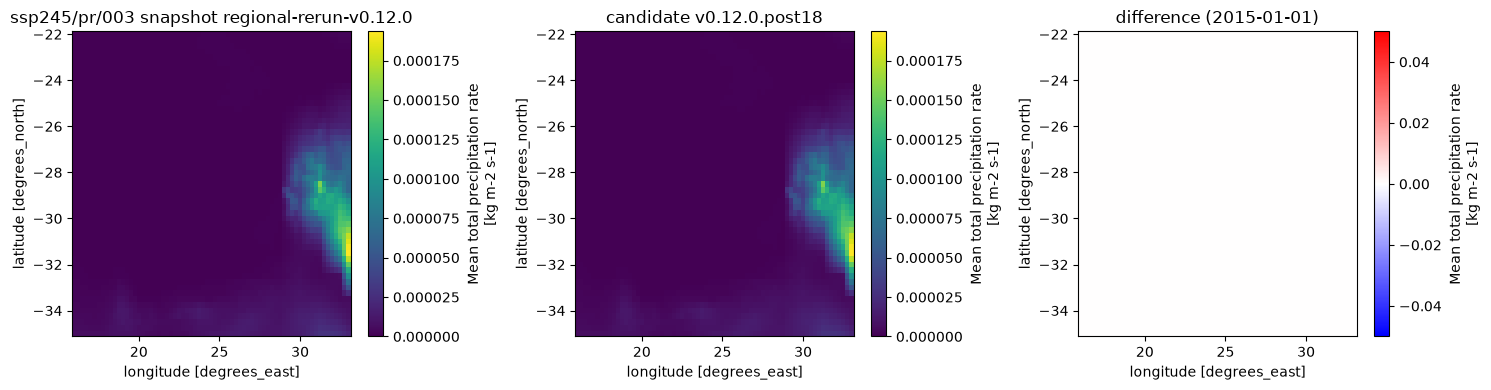

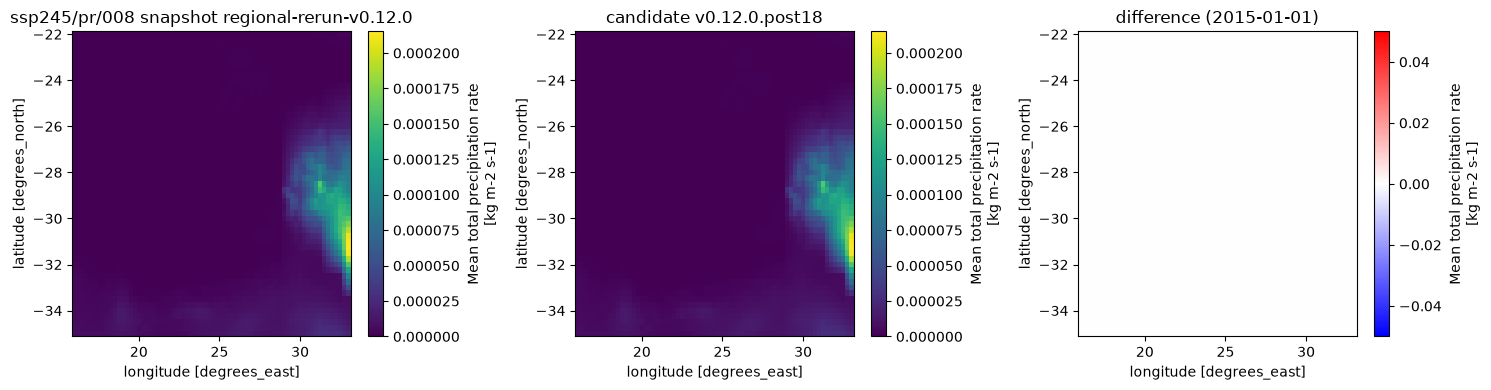

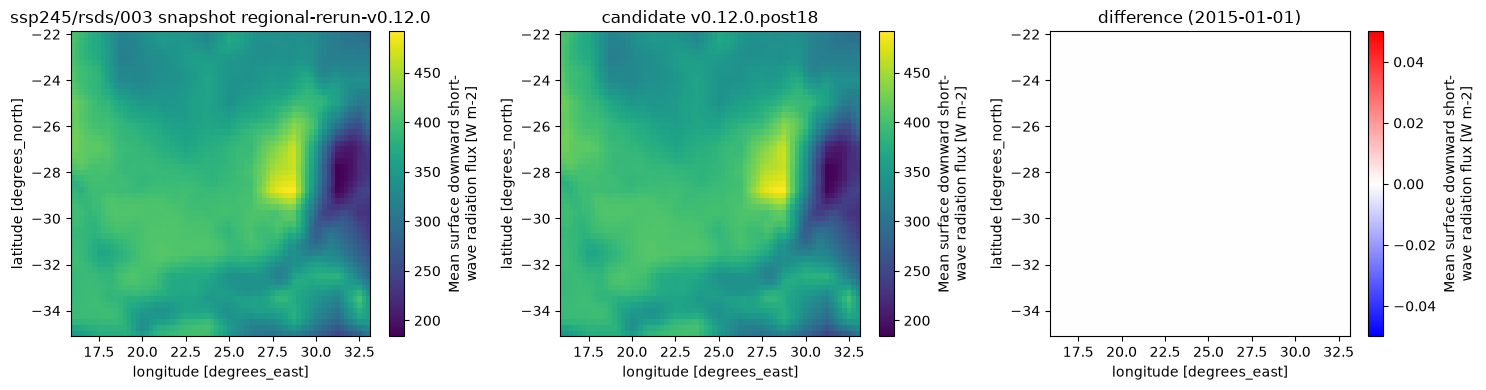

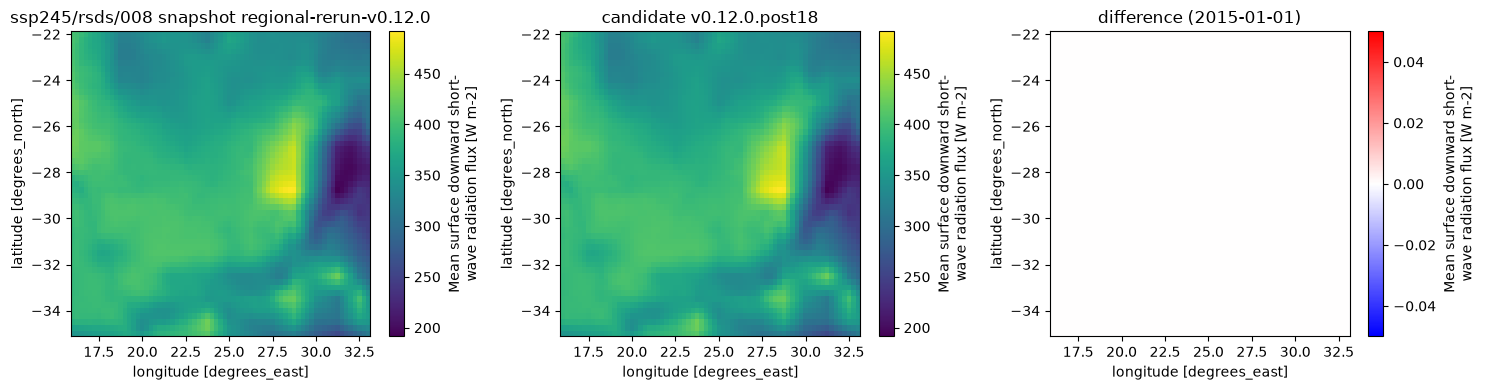

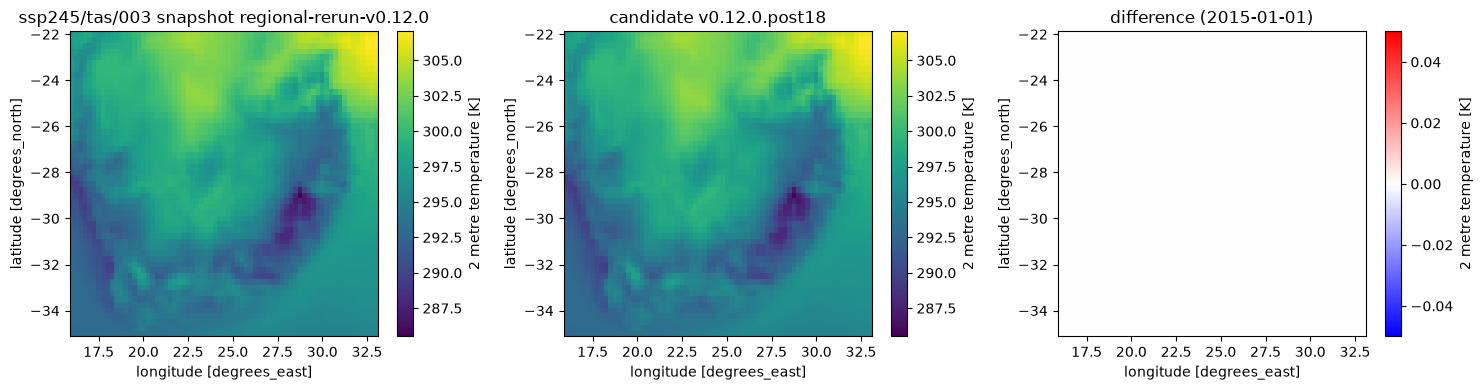

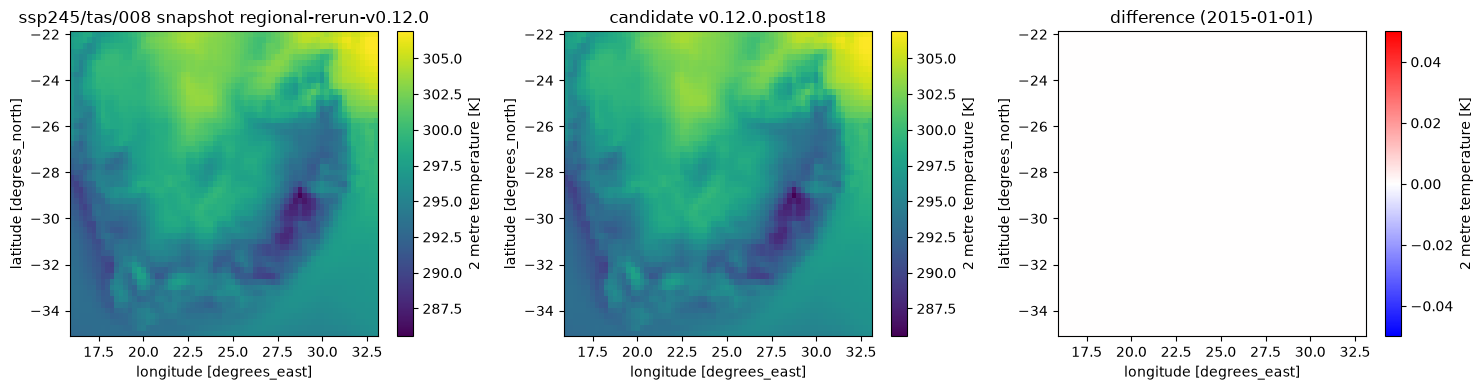

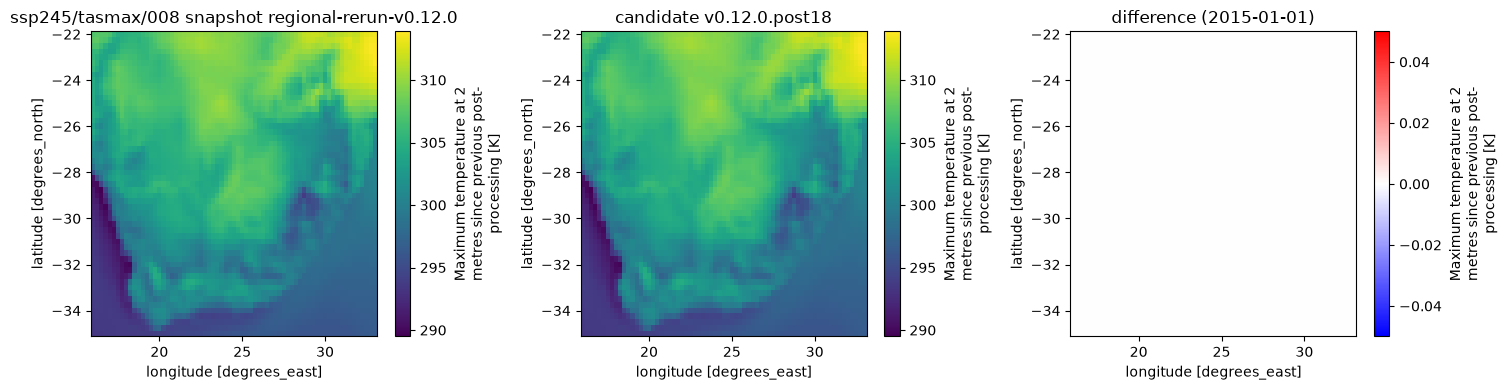

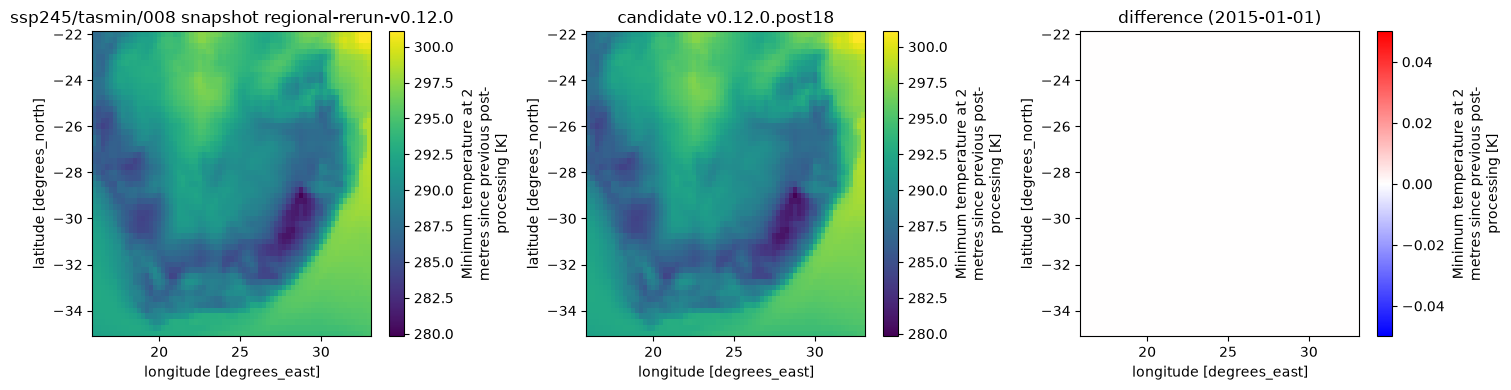

In [10]:
# Difference maps: snapshot vs candidate vs (candidate - snapshot) at one time step,
# one row of maps per ensemble member the two runs share.
for scenario in scen_list:
    snap_vars = set(snapshot_tree[scenario].children)
    cand_vars = set(candidate_tree[scenario].children)
    for variable in sorted(snap_vars & cand_vars):
        if variables and variable not in variables:
            continue
        for member in shared_members(scenario, variable):
            c0 = leaf_da(candidate_tree, scenario, variable, member).isel(time=time_index)
            # Select the snapshot by *label*, not position: isel on both sides would
            # silently compare different dates whenever the two time axes differ in
            # start or length, which is exactly the case a shape mismatch flags.
            s0 = leaf_da(snapshot_tree, scenario, variable, member).sel(time=c0["time"])
            date = str(c0["time"].values)[:10]
            fig, axes = plt.subplots(1, 3, figsize=(15, 4))
            s0.plot(ax=axes[0])
            axes[0].set_title(f"{scenario}/{variable}/{member} snapshot {snapshot_branch}")
            c0.plot(ax=axes[1])
            axes[1].set_title(f"candidate {candidate_branch}")
            (c0 - s0).plot(ax=axes[2], cmap="bwr", center=0)
            axes[2].set_title(f"difference ({date})")
            plt.tight_layout()
            plt.show()

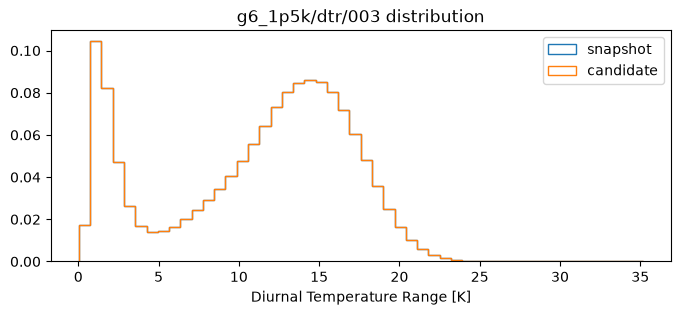

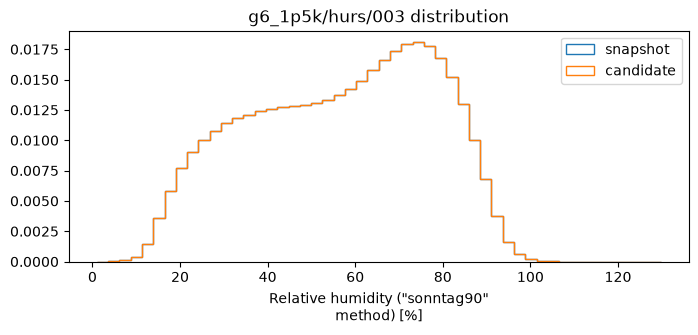

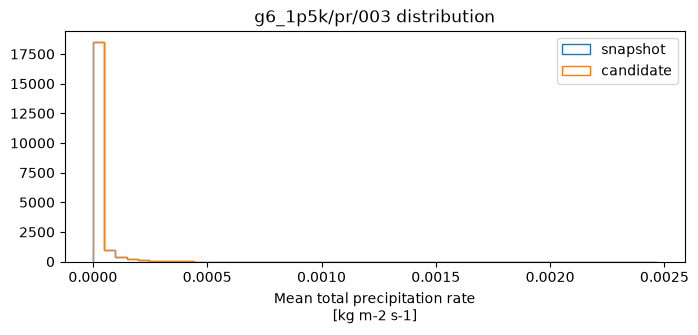

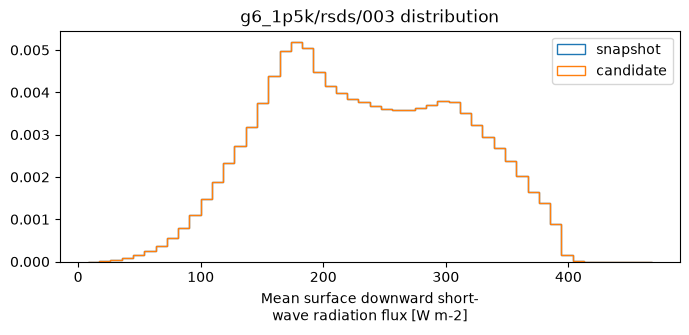

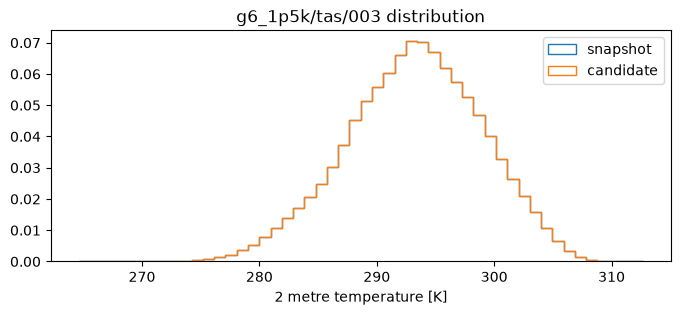

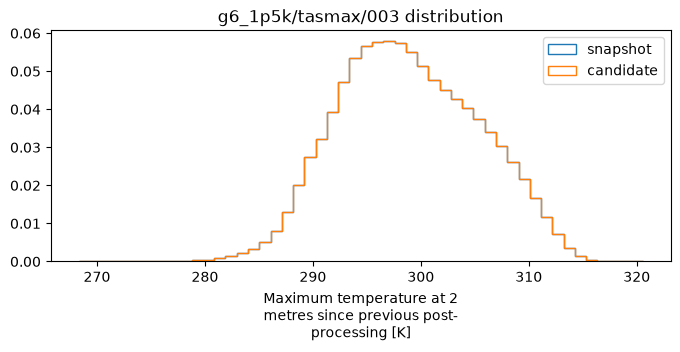

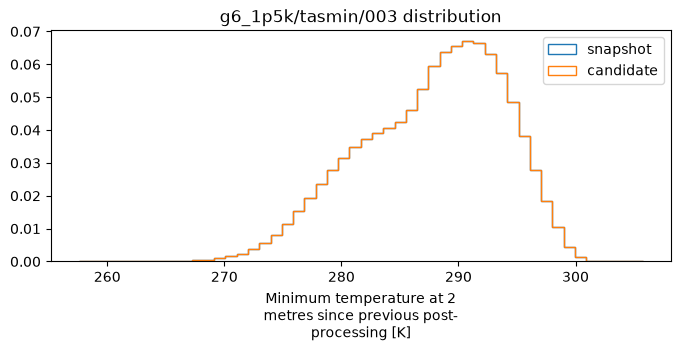

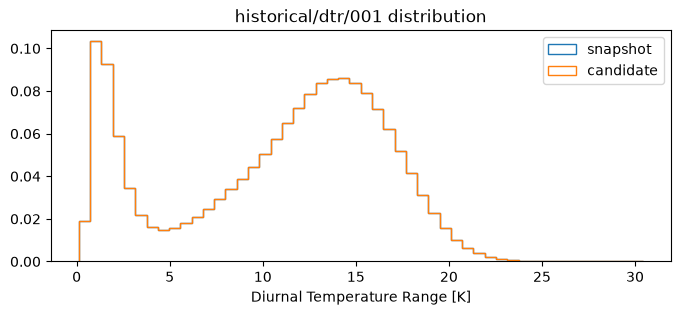

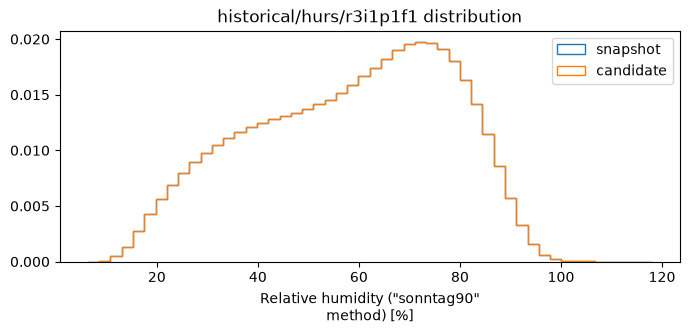

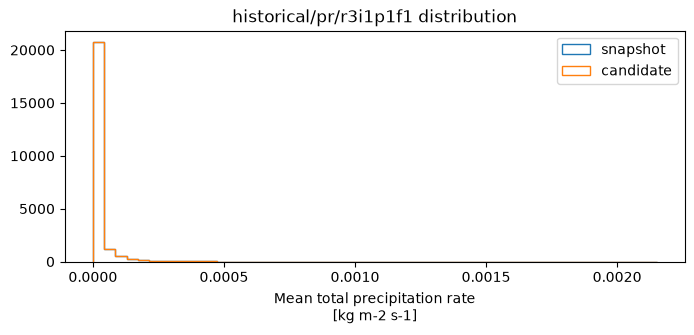

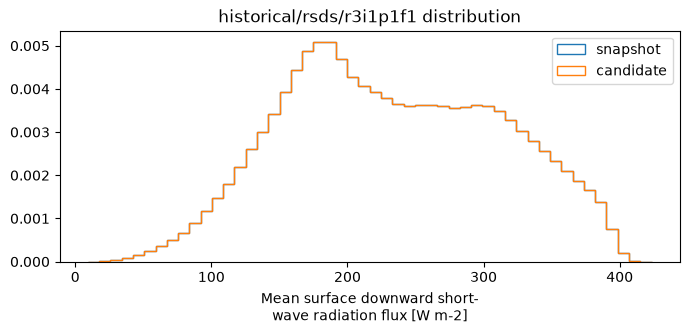

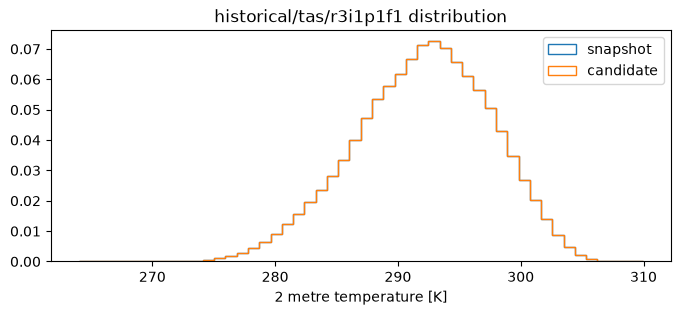

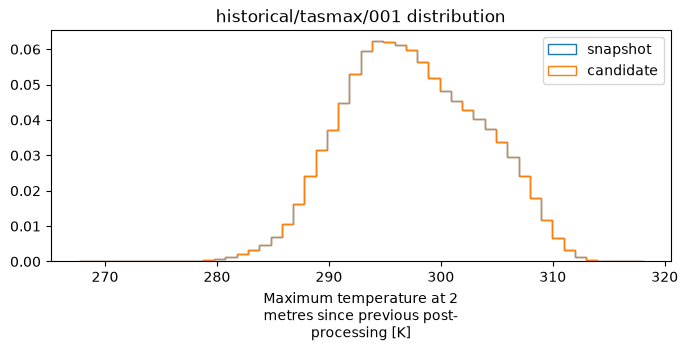

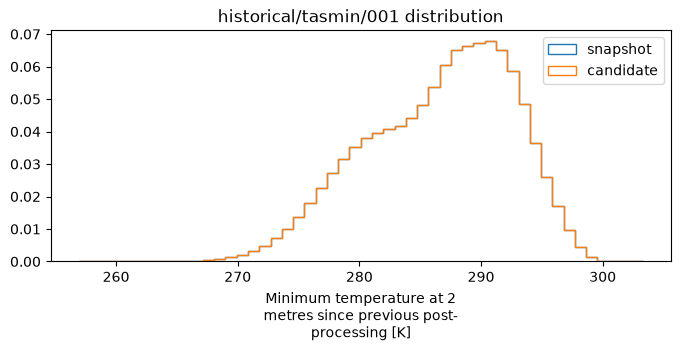

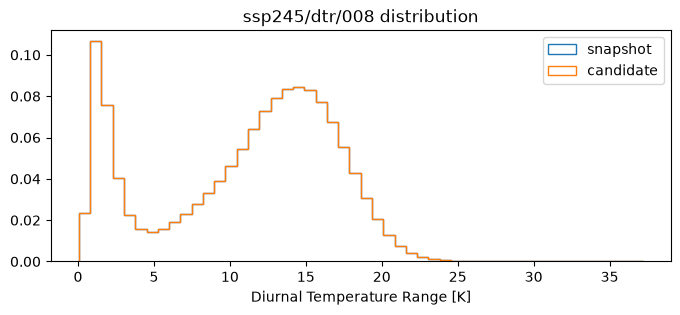

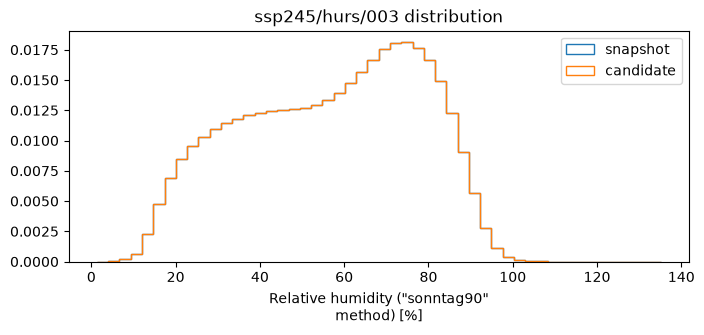

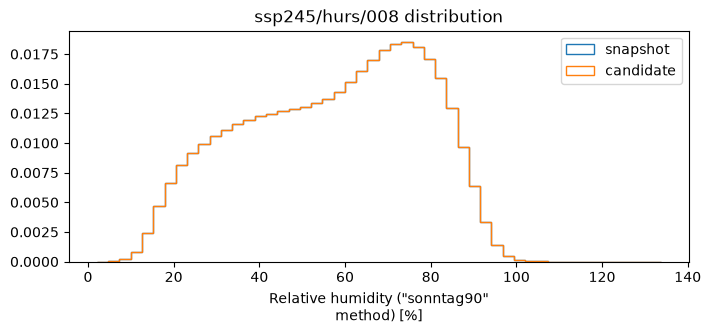

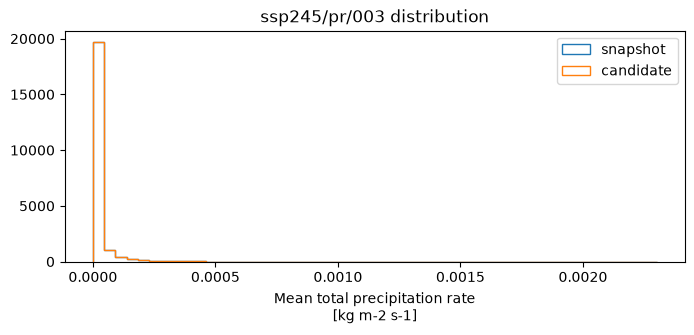

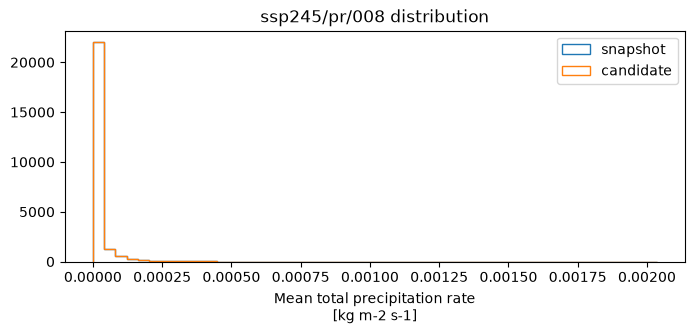

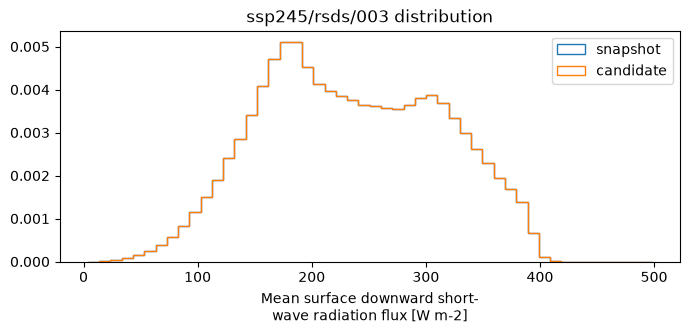

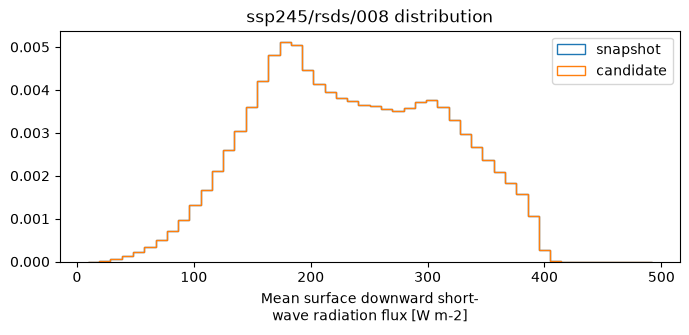

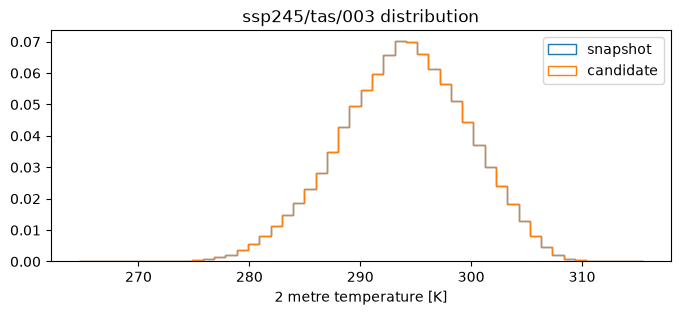

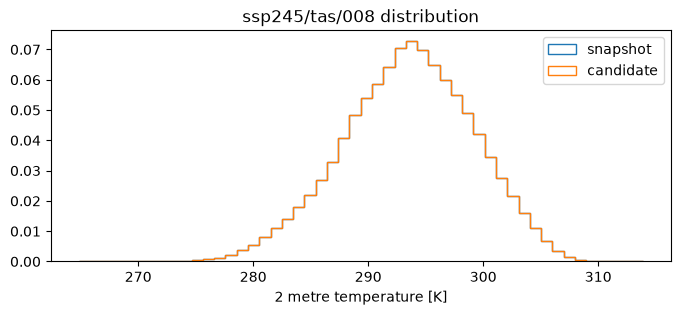

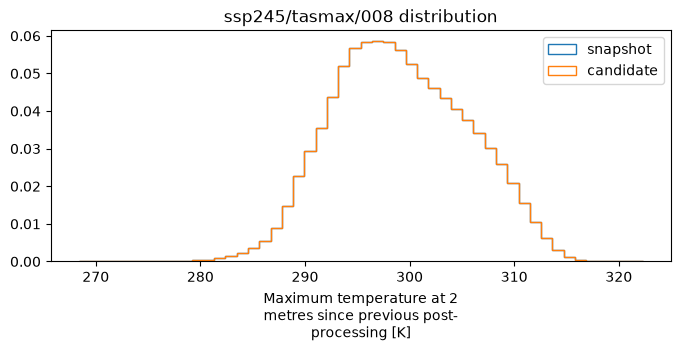

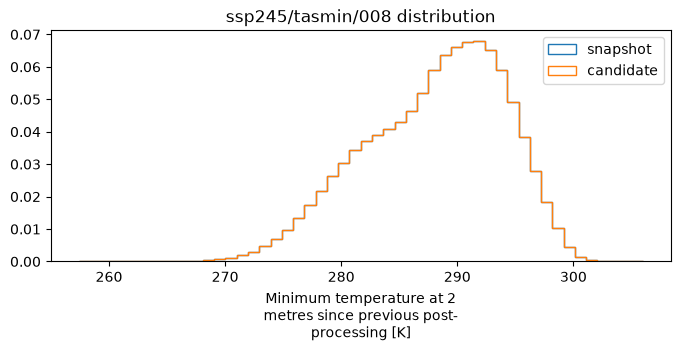

In [11]:
# Value distributions: snapshot vs candidate, per scenario/variable/member.
for scenario in scen_list:
    snap_vars = set(snapshot_tree[scenario].children)
    cand_vars = set(candidate_tree[scenario].children)
    for variable in sorted(snap_vars & cand_vars):
        if variables and variable not in variables:
            continue
        for member in shared_members(scenario, variable):
            s = leaf_da(snapshot_tree, scenario, variable, member)
            c = leaf_da(candidate_tree, scenario, variable, member)
            fig, ax = plt.subplots(figsize=(8, 3))
            s.plot.hist(bins=50, histtype="step", density=True, ax=ax, label="snapshot")
            c.plot.hist(bins=50, histtype="step", density=True, ax=ax, label="candidate")
            ax.set_title(f"{scenario}/{variable}/{member} distribution")
            ax.legend()
            plt.show()

## Verdict

The passes are reported separately because they fail for different reasons and call for
different responses.

| pass fails | reading | response |
|---|---|---|
| configured but never written | the run did not finish | rerun before reading anything else |
| candidate only | new coverage, no baseline counterpart | expected on this branch, see above |
| determinism | the pipeline is not reproducible | fix that first; an exact-equality diff means nothing until it holds |
| candidate NaN | a gate did not hold | investigate |
| leaves differ | judgment call | see `docs/how-to/run-snapshot-tests.md` |

For the 50 shared leaves no difference is expected, since the only behavior change is
scoped to `G6-1.5K-END`. The `changed:` list below also carries the 36 candidate-only
leaves at the structural sentinel `frac>tol=1.000e+00, nan_mismatch=-1`. That signature is
expected only where *Leaf inventory* reports the leaf as candidate-only; on a shared leaf
the same signature is a grid or dimension-name mismatch.

In [12]:
print("inventory:      ", "PASS" if inventory_ok else "FAIL")
print("candidate NaN:  ", "PASS" if not candidate_nan_leaves else "FAIL")
print(
    "vs snapshot:    ",
    "PASS (exact match vs snapshot)" if report.passed else "FAIL (changes detected)",
)
for path in never_written:
    print(f"  configured but never written: {path}")
for path in snapshot_only:
    print(f"  snapshot only, not compared: {path}")
for leaf_path, frac, _ in candidate_nan_leaves:
    print(f"  candidate holds NaN inside the ROI: {leaf_path}  frac={frac:.6f}")
for leaf in sorted(report.leaves, key=lambda lf: lf.path):
    if not leaf.within_tol:
        print(
            f"  changed: {leaf.path}  max_abs={leaf.max_abs_diff:.3e}  "
            f"frac>tol={leaf.frac_over_tol:.3e}  nan_mismatch={leaf.nan_mismatch_count}"
        )
for check in sorted(report.invariant_checks, key=lambda c: c.path):
    if not check.holds:
        print(f"  invariant broken: {check.path}  {check.detail}")

inventory:       FAIL
candidate NaN:   PASS
vs snapshot:     FAIL (changes detected)
  changed: debiased_coarse/g6_1p5k/dtr/002/dtr  max_abs=nan  frac>tol=1.000e+00  nan_mismatch=-1
  changed: debiased_coarse/g6_1p5k/hurs/002/hurs  max_abs=nan  frac>tol=1.000e+00  nan_mismatch=-1
  changed: debiased_coarse/g6_1p5k/pr/002/pr  max_abs=nan  frac>tol=1.000e+00  nan_mismatch=-1
  changed: debiased_coarse/g6_1p5k/rsds/002/rsds  max_abs=nan  frac>tol=1.000e+00  nan_mismatch=-1
  changed: debiased_coarse/g6_1p5k/tas/002/tas  max_abs=nan  frac>tol=1.000e+00  nan_mismatch=-1
  changed: debiased_coarse/g6_1p5k/tasmax/002/tasmax  max_abs=nan  frac>tol=1.000e+00  nan_mismatch=-1
  changed: debiased_coarse/g6_1p5k/tasmin/002/tasmin  max_abs=nan  frac>tol=1.000e+00  nan_mismatch=-1
  changed: debiased_coarse/g6_1p5k_end/dtr/002/dtr  max_abs=nan  frac>tol=1.000e+00  nan_mismatch=-1
  changed: debiased_coarse/g6_1p5k_end/hurs/002/hurs  max_abs=nan  frac>tol=1.000e+00  nan_mismatch=-1
  changed: debiase